# Heightmap CNN Weight Visualizer

Loads a saved policy from any run directory and visualizes the `FTR_HeightmapEncoder` CNN weights.  
No Isaac Sim required — only `torch`, `numpy`, and `matplotlib`.

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
RUN_DIR      = "/home/robot/workspaces/robot_rodeo_gym_ws/runs/best_so_far/TheAshape"
WEIGHTS_FILE = "policy_final.pth"   # or e.g. "policy_step_1048576.pth"

import sys, pathlib, math, warnings
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import norm as scipy_norm

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 9})
warnings.filterwarnings("ignore")

# Make flipper_training importable (needed only for Cell 2 onwards)
FT_SRC = "/home/robot/workspaces/robot_rodeo_gym_ws/src/flipper_training"
if FT_SRC not in sys.path:
    sys.path.insert(0, FT_SRC)

RUN_PATH     = pathlib.Path(RUN_DIR)
WEIGHTS_PATH = RUN_PATH / "weights" / WEIGHTS_FILE
assert WEIGHTS_PATH.exists(), f"File not found: {WEIGHTS_PATH}"
print(f"Run dir : {RUN_PATH}")
print(f"Weights : {WEIGHTS_PATH}")

Run dir : /home/robot/workspaces/robot_rodeo_gym_ws/runs/best_so_far/TheAshape
Weights : /home/robot/workspaces/robot_rodeo_gym_ws/runs/best_so_far/TheAshape/weights/policy_final.pth


In [2]:
# ── Load policy and extract CNN sub-state-dict ────────────────────────────────
sd = torch.load(WEIGHTS_PATH, map_location="cpu", weights_only=True)

# Auto-detect which observation encoder contains the CNN
cnn_keys = [k for k in sd.keys() if ".cnn." in k]
assert cnn_keys, "No .cnn. keys found — this run may not use a CNN encoder"

# Derive the common prefix (everything up to and including '.cnn.')
# e.g. 'module.0.module.0.module.0.module.encoders.FtrFlatObservation.cnn.'
sample_key = cnn_keys[0]
cnn_prefix = sample_key[: sample_key.index(".cnn.") + 5]  # inclusive of '.cnn.'
obs_name   = cnn_prefix.split(".encoders.")[1].split(".")[0]
print(f"Encoder class : {obs_name}")
print(f"CNN prefix    : {cnn_prefix}")

# Build sub-dict with keys relative to the CNN module root
# e.g. 'encoder.0.weight', 'encoder.0.bias', ...
cnn_sd = {k[len(cnn_prefix):]: v for k, v in sd.items() if k.startswith(cnn_prefix)}

# Print architecture summary
LAYER_LABELS = {
    "encoder.0": "Conv2d-1  (1→16, 3×3, dil=2)",
    "encoder.2": "Conv2d-2  (16→32, 3×3)",
    "encoder.4": "Conv2d-3  (32→64, 4×2)",
    "encoder.8": "Linear    (256→out)",
}
print()
print(f"{'Key':<30} {'Shape':<20} {'Params':>8}")
print("-" * 62)
for k, v in sorted(cnn_sd.items()):
    prefix_k = k.rsplit(".", 1)[0]
    label = LAYER_LABELS.get(prefix_k, "")
    print(f"{k:<30} {str(list(v.shape)):<20} {v.numel():>8,}   {label}")

# Convenience references
W0 = cnn_sd["encoder.0.weight"]   # [16, 1, 3, 3]
W2 = cnn_sd["encoder.2.weight"]   # [32, 16, 3, 3]
W4 = cnn_sd["encoder.4.weight"]   # [64, 32, 4, 2]
W8 = cnn_sd["encoder.8.weight"]   # [out_dim, 256]
print()
print(f"CNN output_dim = {W8.shape[0]}")

Encoder class : FtrFlatObservation
CNN prefix    : module.0.module.0.module.0.module.encoders.FtrFlatObservation.cnn.

Key                            Shape                  Params
--------------------------------------------------------------
encoder.0.bias                 [16]                       16   Conv2d-1  (1→16, 3×3, dil=2)
encoder.0.weight               [16, 1, 3, 3]             144   Conv2d-1  (1→16, 3×3, dil=2)
encoder.2.bias                 [32]                       32   Conv2d-2  (16→32, 3×3)
encoder.2.weight               [32, 16, 3, 3]          4,608   Conv2d-2  (16→32, 3×3)
encoder.4.bias                 [64]                       64   Conv2d-3  (32→64, 4×2)
encoder.4.weight               [64, 32, 4, 2]         16,384   Conv2d-3  (32→64, 4×2)
encoder.8.bias                 [128]                     128   Linear    (256→out)
encoder.8.weight               [128, 256]             32,768   Linear    (256→out)

CNN output_dim = 128


In [3]:
# ── Reconstruct FTR_HeightmapEncoder (no Isaac Sim needed) ───────────────────
from flipper_training.observations.heightmap import FTR_HeightmapEncoder

output_dim = W8.shape[0]
cnn_model  = FTR_HeightmapEncoder(img_shape=(45, 21), output_dim=output_dim)
missing, unexpected = cnn_model.load_state_dict(cnn_sd, strict=False)
cnn_model.eval()

if missing:
    print(f"Missing keys  : {missing}")
if unexpected:
    print(f"Unexpected keys: {unexpected}")
print(f"CNN model loaded — output_dim={output_dim}")
print(cnn_model)

/home/robot/workspaces/robot_rodeo_gym_ws
CNN model loaded — output_dim=128
FTR_HeightmapEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), dilation=(2, 2))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(4, 2), stride=(1, 1))
    (5): ReLU(inplace=True)
    (6): AdaptiveAvgPool2d(output_size=(2, 2))
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): Identity()
  )
)


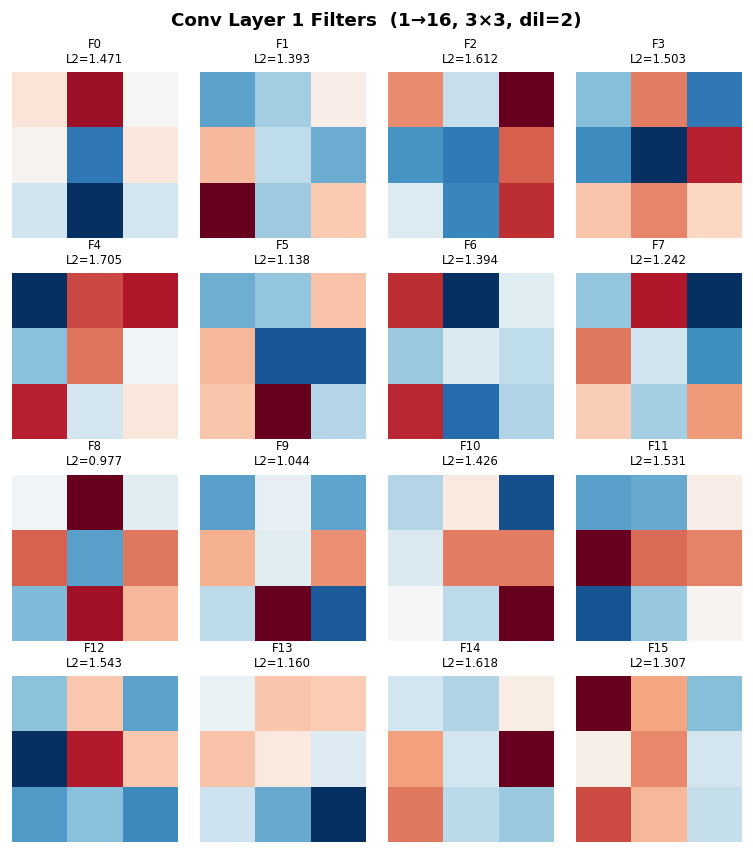

In [4]:
# ── Cell 3: Layer 0 filters — 4×4 grid of 3×3 images ────────────────────────
# W0 shape: [16, 1, 3, 3]  →  16 single-channel 3×3 filters
n_filters = W0.shape[0]
cols = 4
rows = math.ceil(n_filters / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
fig.suptitle("Conv Layer 1 Filters  (1→16, 3×3, dil=2)", fontsize=11, fontweight="bold")

for i, ax in enumerate(axes.flat):
    if i < n_filters:
        filt = W0[i, 0].numpy()          # [3, 3]
        norm  = np.linalg.norm(filt)
        vabs  = max(abs(filt.max()), abs(filt.min()), 1e-6)
        ax.imshow(filt, cmap="RdBu_r", vmin=-vabs, vmax=vabs, interpolation="nearest")
        ax.set_title(f"F{i}\nL2={norm:.3f}", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

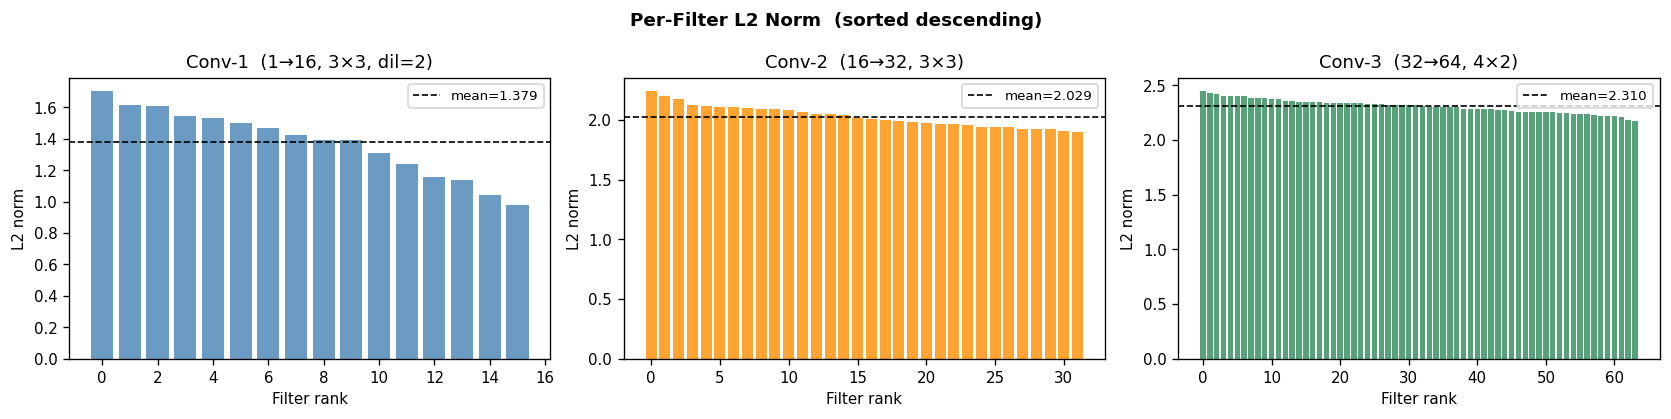

In [5]:
# ── Cell 4: Per-filter L2 norms across all 3 conv layers ─────────────────────
def filter_norms(W):
    """L2 norm per output filter (flatten over in_ch, kH, kW)."""
    return W.reshape(W.shape[0], -1).norm(dim=1).numpy()

layers = [
    (W0, "Conv-1  (1→16, 3×3, dil=2)",  "steelblue"),
    (W2, "Conv-2  (16→32, 3×3)",         "darkorange"),
    (W4, "Conv-3  (32→64, 4×2)",         "seagreen"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
fig.suptitle("Per-Filter L2 Norm  (sorted descending)", fontsize=11, fontweight="bold")

for ax, (W, label, color) in zip(axes, layers):
    norms = filter_norms(W)
    norms_sorted = np.sort(norms)[::-1]
    ax.bar(range(len(norms_sorted)), norms_sorted, color=color, alpha=0.8)
    ax.axhline(norms_sorted.mean(), color="black", ls="--", lw=1, label=f"mean={norms_sorted.mean():.3f}")
    ax.set_title(label)
    ax.set_xlabel("Filter rank")
    ax.set_ylabel("L2 norm")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

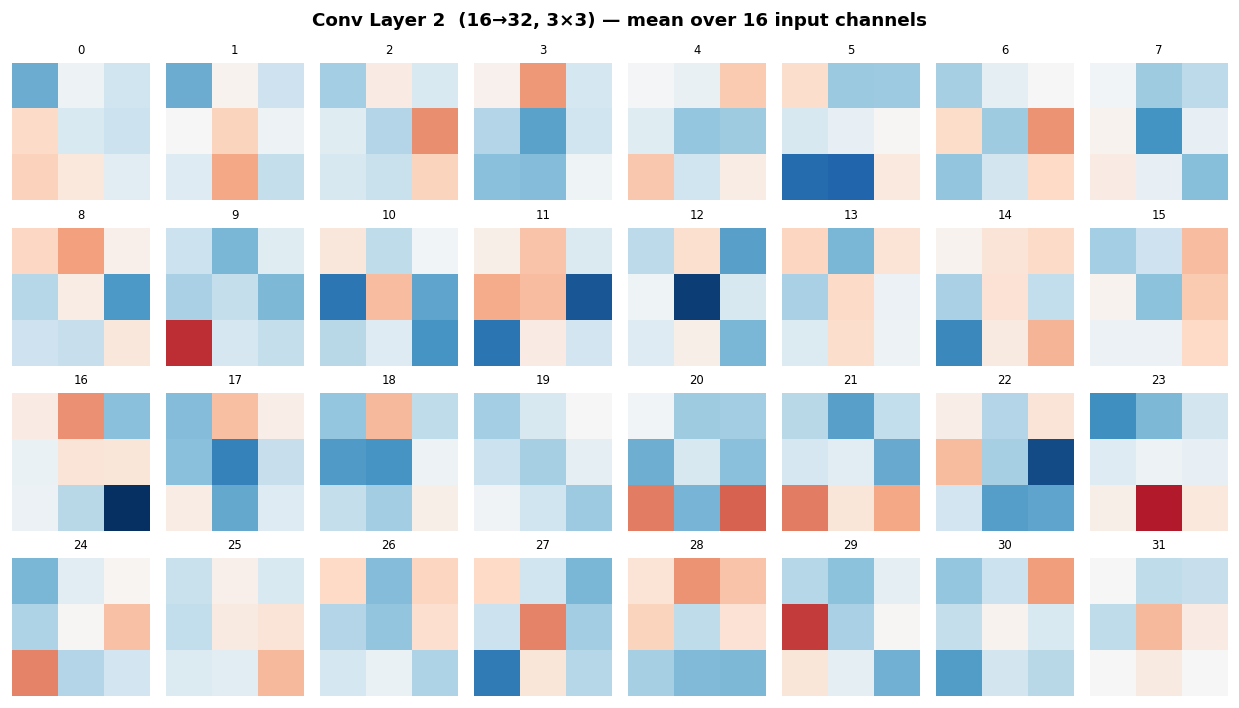

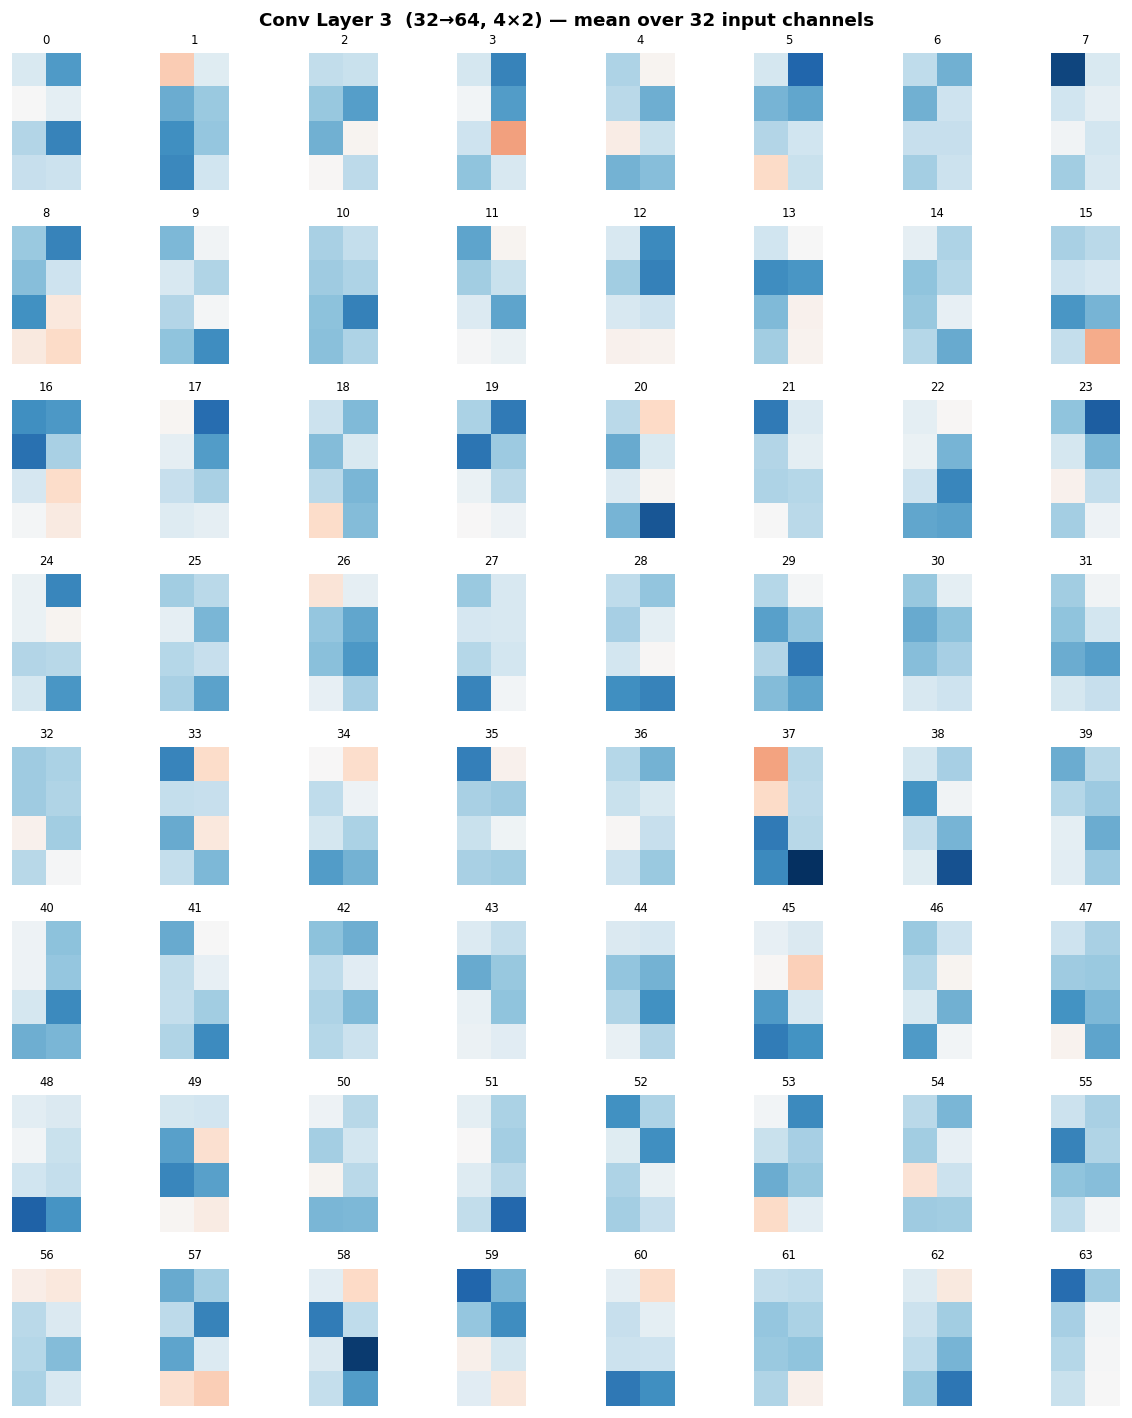

In [6]:
# ── Cell 5: Mean-over-input-channels view of deeper filters ──────────────────
# Shows the spatial pattern each output filter is sensitive to on average.

def plot_filter_grid(W, title, cols=8):
    """W: [out_ch, in_ch, kH, kW]. Plot mean over in_ch for each out filter."""
    mean_filt = W.mean(dim=1).numpy()   # [out_ch, kH, kW]
    n = mean_filt.shape[0]
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.3, rows * 1.5))
    fig.suptitle(title, fontsize=11, fontweight="bold")
    vabs = max(abs(mean_filt.max()), abs(mean_filt.min()), 1e-6)
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(mean_filt[i], cmap="RdBu_r", vmin=-vabs, vmax=vabs, interpolation="nearest")
            ax.set_title(f"{i}", fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_filter_grid(W2, "Conv Layer 2  (16→32, 3×3) — mean over 16 input channels", cols=8)
plot_filter_grid(W4, "Conv Layer 3  (32→64, 4×2) — mean over 32 input channels", cols=8)

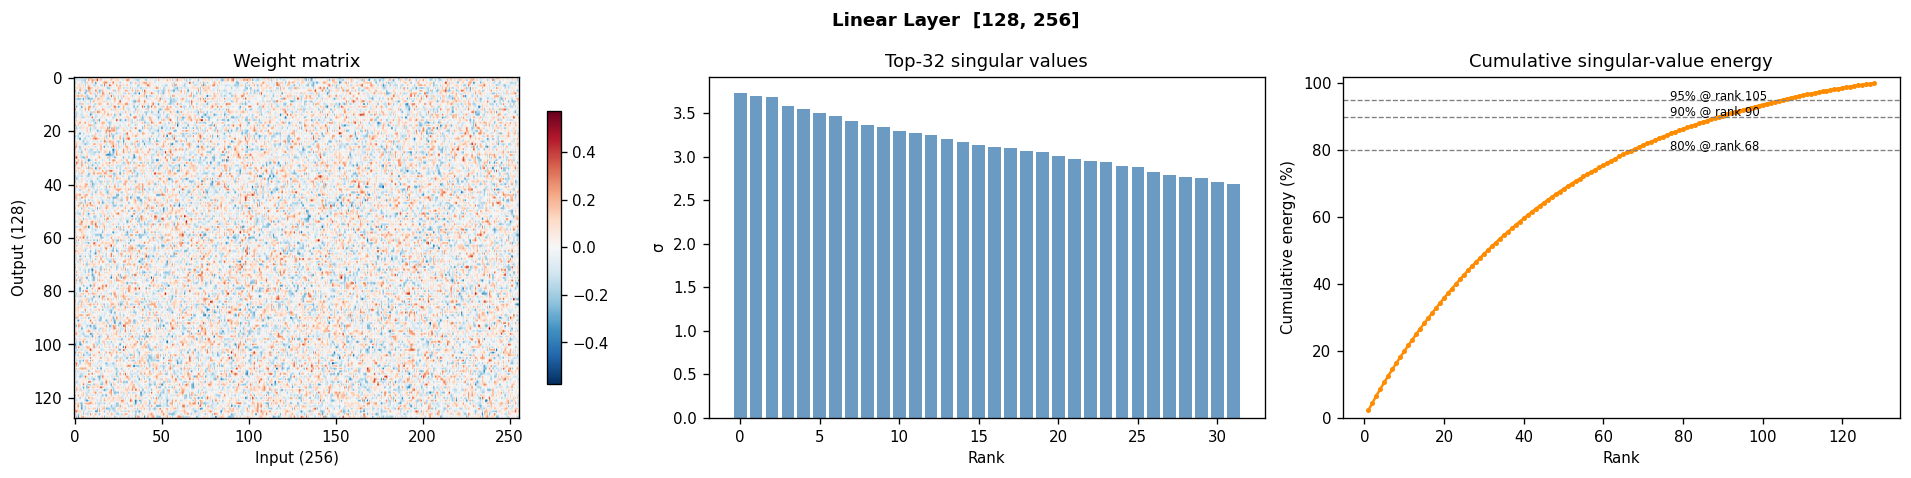

In [7]:
# ── Cell 6: Linear layer heatmap + singular value spectrum ───────────────────
W8_np = W8.numpy()   # [out_dim, 256]
U, S, Vt = np.linalg.svd(W8_np, full_matrices=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Linear Layer  {list(W8_np.shape)}", fontsize=11, fontweight="bold")

# Weight heatmap
vabs = np.abs(W8_np).max()
im = axes[0].imshow(W8_np, cmap="RdBu_r", vmin=-vabs, vmax=vabs, aspect="auto")
axes[0].set_title("Weight matrix")
axes[0].set_xlabel("Input (256)")
axes[0].set_ylabel(f"Output ({W8_np.shape[0]})")
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Singular values
n_sv = min(len(S), 32)
axes[1].bar(range(n_sv), S[:n_sv], color="steelblue", alpha=0.8)
axes[1].set_title(f"Top-{n_sv} singular values")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("σ")

# Cumulative energy
cumvar = np.cumsum(S**2) / (S**2).sum() * 100
axes[2].plot(range(1, len(S)+1), cumvar, marker=".", markersize=4, color="darkorange")
for pct in [80, 90, 95]:
    rank = int(np.searchsorted(cumvar, pct)) + 1
    axes[2].axhline(pct, color="grey", lw=0.8, ls="--")
    axes[2].text(len(S) * 0.6, pct + 0.5, f"{pct}% @ rank {rank}", fontsize=7)
axes[2].set_title("Cumulative singular-value energy")
axes[2].set_xlabel("Rank")
axes[2].set_ylabel("Cumulative energy (%)")
axes[2].set_ylim(0, 102)

plt.tight_layout()
plt.show()

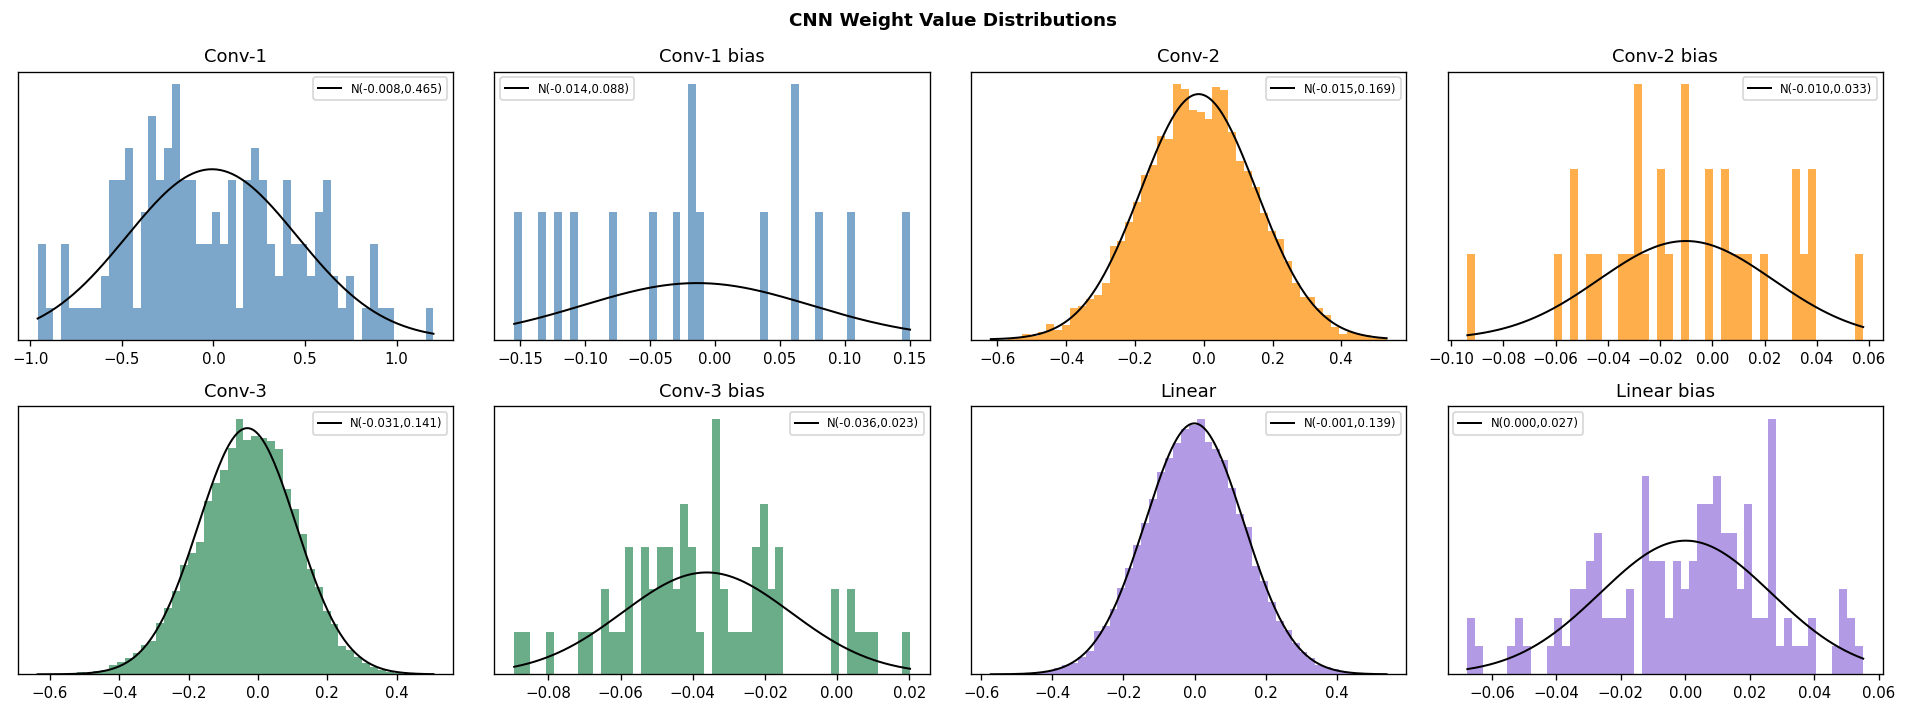

In [8]:
# ── Cell 7: Weight value distributions ───────────────────────────────────────
layers_all = [
    (W0, "Conv-1",  "steelblue"),
    (cnn_sd["encoder.0.bias"],  "Conv-1 bias",  "steelblue"),
    (W2, "Conv-2",  "darkorange"),
    (cnn_sd["encoder.2.bias"],  "Conv-2 bias",  "darkorange"),
    (W4, "Conv-3",  "seagreen"),
    (cnn_sd["encoder.4.bias"],  "Conv-3 bias",  "seagreen"),
    (W8, "Linear",  "mediumpurple"),
    (cnn_sd["encoder.8.bias"],  "Linear bias", "mediumpurple"),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle("CNN Weight Value Distributions", fontsize=11, fontweight="bold")

for ax, (W, label, color) in zip(axes.flat, layers_all):
    vals = W.numpy().ravel()
    ax.hist(vals, bins=50, color=color, alpha=0.7, density=True)
    # Gaussian reference
    mu, sigma = vals.mean(), vals.std()
    xs = np.linspace(vals.min(), vals.max(), 200)
    ax.plot(xs, scipy_norm.pdf(xs, mu, sigma), color="black", lw=1.2, label=f"N({mu:.3f},{sigma:.3f})")
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.tight_layout()
plt.show()

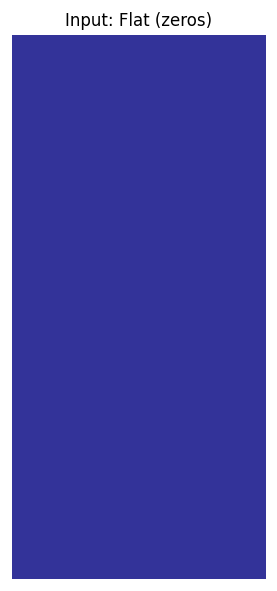

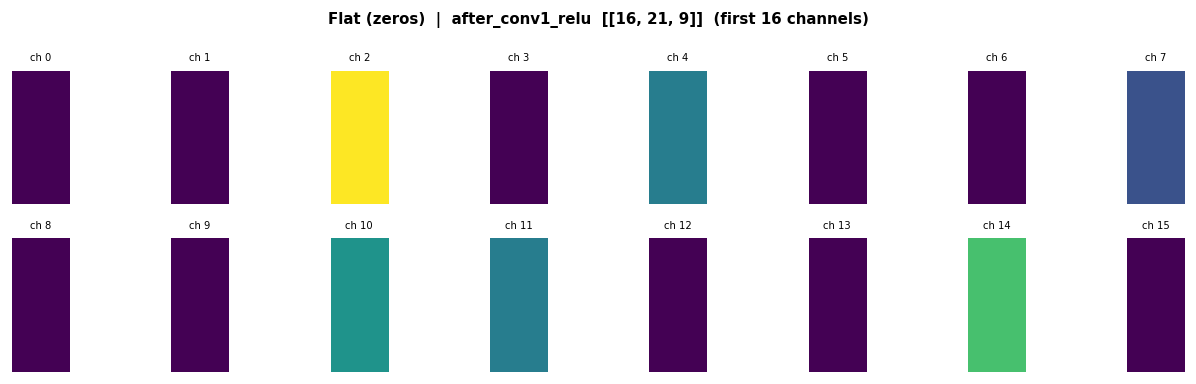

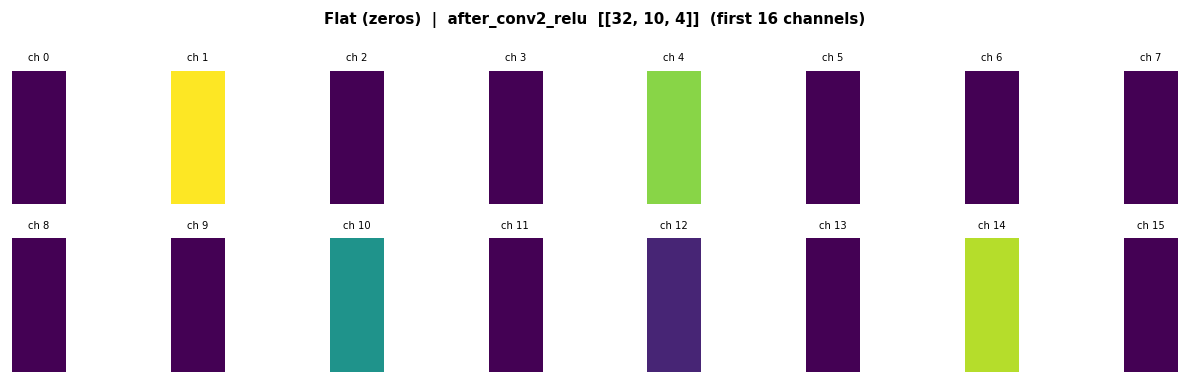

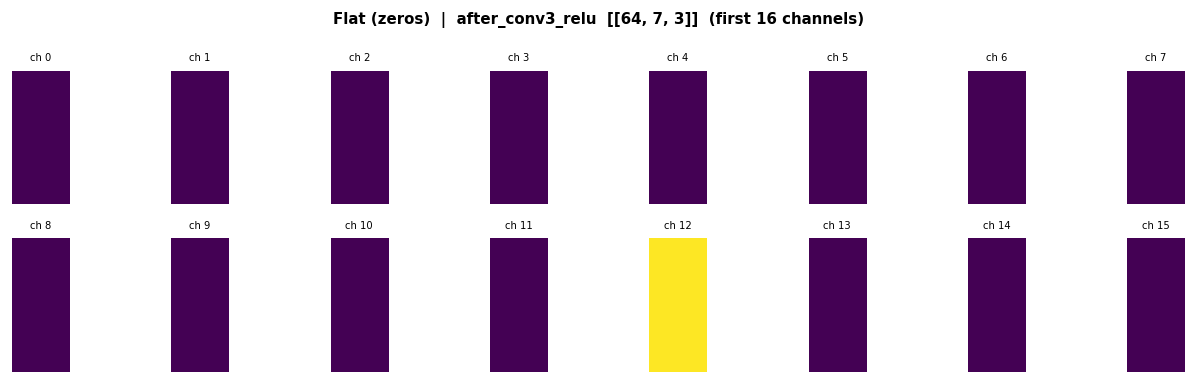

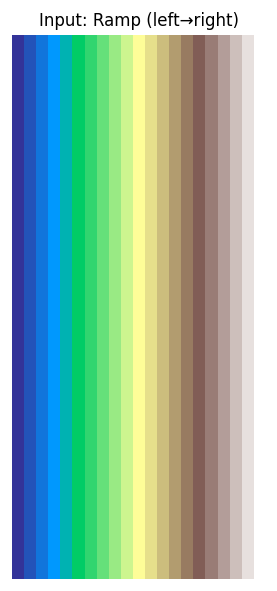

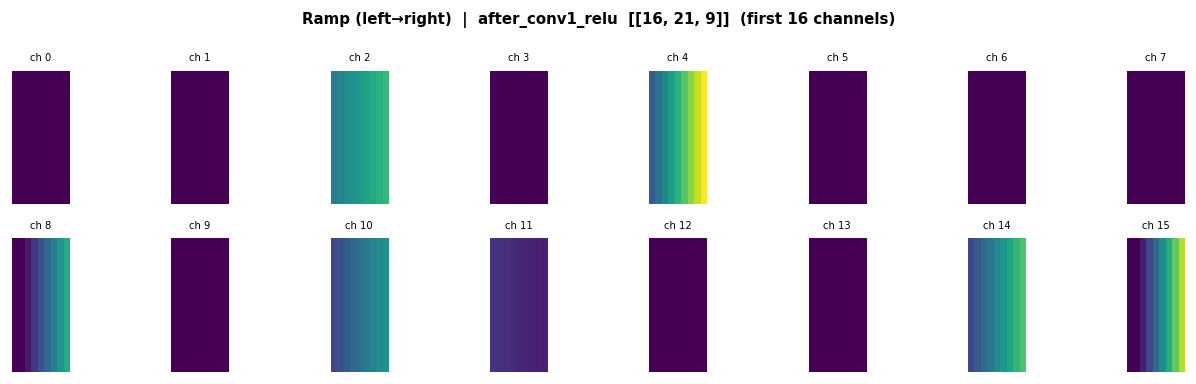

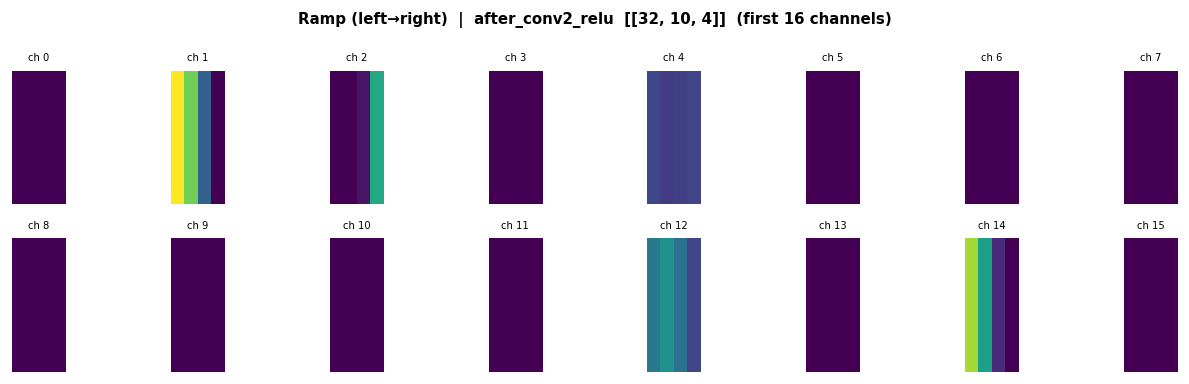

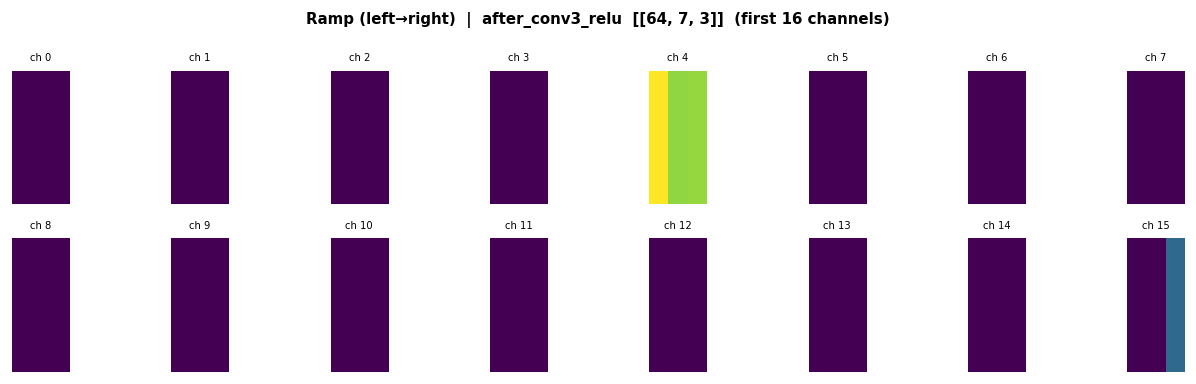

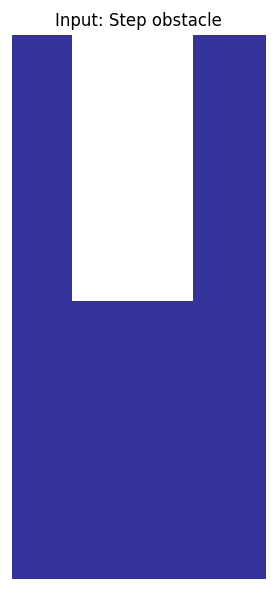

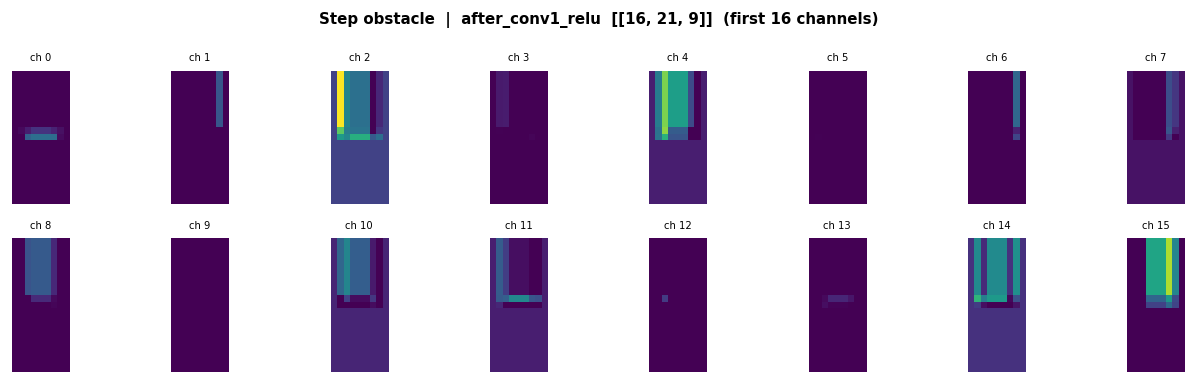

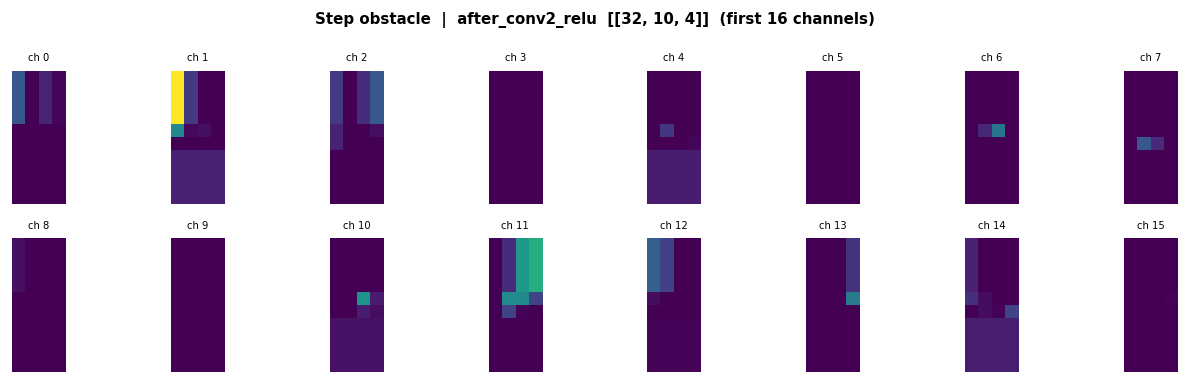

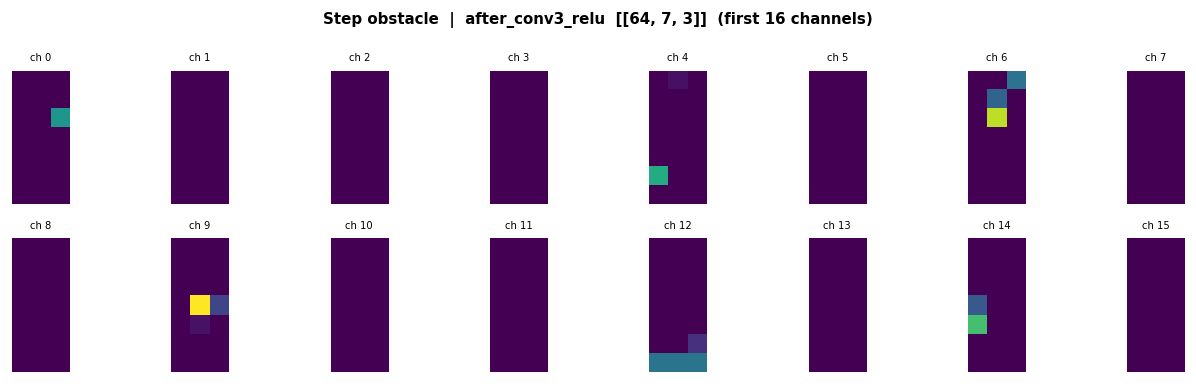

In [9]:
# ── Cell 8: Feature maps on synthetic heightmaps ─────────────────────────────
# Runs 3 synthetic inputs through the reconstructed CNN and plots
# intermediate activations after each Conv+ReLU block.

H, W = 45, 21

def make_flat():
    return torch.zeros(1, 1, H, W)

def make_ramp():
    t = torch.linspace(0, 0.5, W).unsqueeze(0).expand(H, -1)
    return t.unsqueeze(0).unsqueeze(0)

def make_step():
    hm = torch.zeros(H, W)
    # Step: top-centre block elevated by 0.3 m (robot approaching from bottom)
    hm[:H//2, W//4: 3*W//4] = 0.3
    return hm.unsqueeze(0).unsqueeze(0)

INPUTS = {
    "Flat (zeros)": make_flat(),
    "Ramp (left→right)": make_ramp(),
    "Step obstacle": make_step(),
}

# Register forward hooks to capture intermediate feature maps
hook_outputs = {}

def make_hook(name):
    def hook(module, inp, out):
        hook_outputs[name] = out.detach()
    return hook

handles = [
    cnn_model.encoder[1].register_forward_hook(make_hook("after_conv1_relu")),  # ReLU after conv1
    cnn_model.encoder[3].register_forward_hook(make_hook("after_conv2_relu")),  # ReLU after conv2
    cnn_model.encoder[5].register_forward_hook(make_hook("after_conv3_relu")),  # ReLU after conv3
]

def plot_feature_maps(fmaps, title, max_ch=16, cols=8):
    """fmaps: [1, C, H, W]"""
    fmaps = fmaps[0].numpy()  # [C, H, W]
    n = min(fmaps.shape[0], max_ch)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 1.6))
    fig.suptitle(title, fontsize=9, fontweight="bold")
    vabs = max(abs(fmaps[:n].max()), abs(fmaps[:n].min()), 1e-6)
    for i, ax in enumerate(axes.flat if hasattr(axes, 'flat') else [axes]):
        if i < n:
            ax.imshow(fmaps[i], cmap="viridis", vmin=0, vmax=vabs, interpolation="nearest")
            ax.set_title(f"ch {i}", fontsize=6)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

with torch.no_grad():
    for inp_name, x in INPUTS.items():
        hook_outputs.clear()
        _ = cnn_model(x)

        # Also show the raw input heightmap
        fig, ax = plt.subplots(1, 1, figsize=(3, 5))
        ax.imshow(x[0, 0].numpy(), cmap="terrain", origin="upper")
        ax.set_title(f"Input: {inp_name}", fontsize=10)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

        for hook_name, fmaps in hook_outputs.items():
            plot_feature_maps(
                fmaps,
                f"{inp_name}  |  {hook_name}  [{list(fmaps.shape[1:])}]  (first 16 channels)",
                max_ch=16,
                cols=8,
            )

for h in handles:
    h.remove()

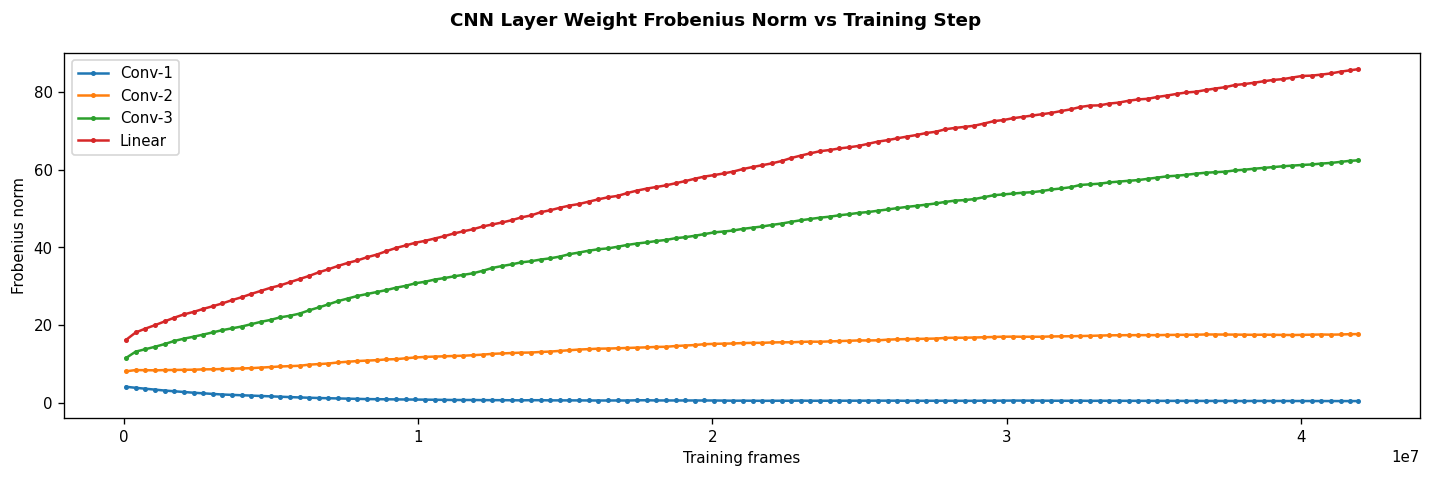

Plotted 129 checkpoints from 65,536 to 41,943,040 frames.


In [10]:
# ── Cell 9: CNN weight norm evolution over training checkpoints ───────────────
import re

ckpt_files = sorted(
    (RUN_PATH / "weights").glob("policy_step_*.pth"),
    key=lambda p: int(re.search(r"policy_step_(\d+)\.pth", p.name).group(1)),
)

if not ckpt_files:
    print("No policy_step_*.pth checkpoints found — skipping evolution plot.")
else:
    steps  = []
    norms0 = []
    norms2 = []
    norms4 = []
    norms8 = []

    for ckpt in ckpt_files:
        step = int(re.search(r"policy_step_(\d+)\.pth", ckpt.name).group(1))
        sd_c = torch.load(ckpt, map_location="cpu", weights_only=True)
        csd  = {k[k.index(".cnn.") + 5:]: v for k, v in sd_c.items() if ".cnn." in k}
        steps.append(step)
        norms0.append(csd["encoder.0.weight"].norm().item())
        norms2.append(csd["encoder.2.weight"].norm().item())
        norms4.append(csd["encoder.4.weight"].norm().item())
        norms8.append(csd["encoder.8.weight"].norm().item())

    fig, ax = plt.subplots(figsize=(12, 4))
    fig.suptitle("CNN Layer Weight Frobenius Norm vs Training Step", fontsize=11, fontweight="bold")
    ax.plot(steps, norms0, label="Conv-1",  marker=".", markersize=4)
    ax.plot(steps, norms2, label="Conv-2",  marker=".", markersize=4)
    ax.plot(steps, norms4, label="Conv-3",  marker=".", markersize=4)
    ax.plot(steps, norms8, label="Linear",  marker=".", markersize=4)
    ax.set_xlabel("Training frames")
    ax.set_ylabel("Frobenius norm")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Plotted {len(steps)} checkpoints from {steps[0]:,} to {steps[-1]:,} frames.")